In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from wordcloud import WordCloud

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Load Dataset

In [2]:
df = pd.read_csv("spam.csv", encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Remove extra coloumns

In [3]:
df = df[['v1','v2']]
df.columns = ['label','message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Dataset information

In [4]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,0
label,0
message,0


# Class Distribution

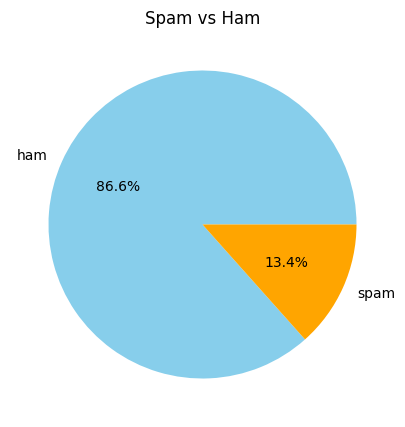

In [5]:
df['label'].value_counts()
plt.figure(figsize=(5,5))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','orange']
)

plt.ylabel("")
plt.title("Spam vs Ham")
plt.show()

# Text Preprocessing

In [11]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))
def preprocess(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    words = [stemmer.stem(word)
             for word in words
             if word not in stop_words]

    return " ".join(words)
df['clean_message'] = df['message'].apply(preprocess)

# Markdown Cell
## TF-IDF Vectorizer

TF-IDF (Term Frequency-Inverse Document Frequency) converts text into numerical vectors by assigning higher importance to words that occur frequently within a document but rarely across all documents. It reduces the impact of common words while emphasizing unique and informative terms, making it effective for text classification tasks such as spam detection.

# Encode Labs

In [9]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

# TF-IDF

In [12]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_message'])

y = df['label']

# Train test Split

In [13]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Model 1
## Multinomial Naive Bayes

In [14]:
nb = MultinomialNB()

nb.fit(X_train,y_train)

y_pred_nb = nb.predict(X_test)

# Evaluation

In [15]:
print("Accuracy :",accuracy_score(y_test,y_pred_nb))

print("Precision :",precision_score(y_test,y_pred_nb))

print("Recall :",recall_score(y_test,y_pred_nb))

print("F1 :",f1_score(y_test,y_pred_nb))

Accuracy : 0.9713004484304932
Precision : 1.0
Recall : 0.7866666666666666
F1 : 0.8805970149253731


# Confusion Matrix

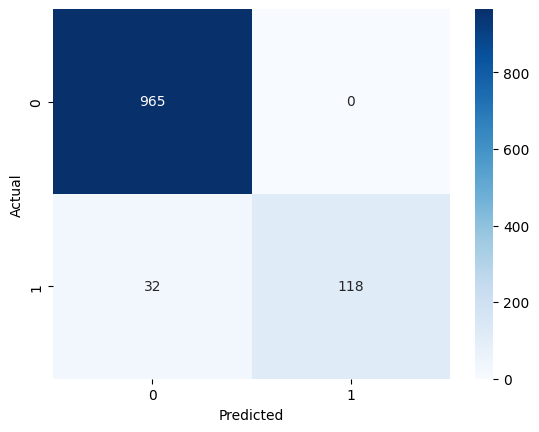

In [16]:
cm = confusion_matrix(y_test,y_pred_nb)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report

In [17]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

# Model 2
## Logistic Regression

In [18]:
lr = LogisticRegression()

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

# Evaluation

In [19]:
print("Accuracy :",accuracy_score(y_test,y_pred_lr))

print("Precision :",precision_score(y_test,y_pred_lr))

print("Recall :",recall_score(y_test,y_pred_lr))

print("F1 :",f1_score(y_test,y_pred_lr))

Accuracy : 0.9488789237668162
Precision : 0.9603960396039604
Recall : 0.6466666666666666
F1 : 0.7729083665338645


# Confusion Matrix

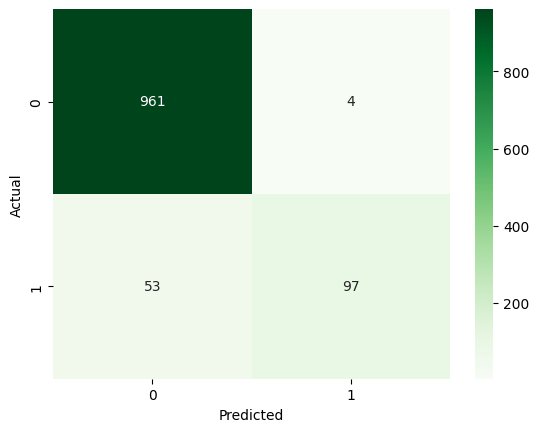

In [20]:
cm = confusion_matrix(y_test,y_pred_lr)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Spam wordcloud

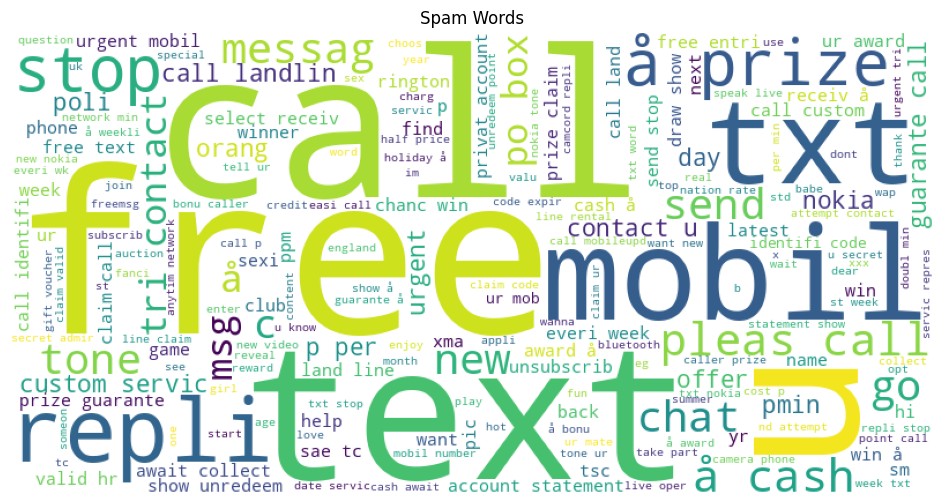

In [21]:
spam_words = " ".join(df[df['label']==1]['clean_message'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Spam Words")
plt.show()

# Ham Wordcloud

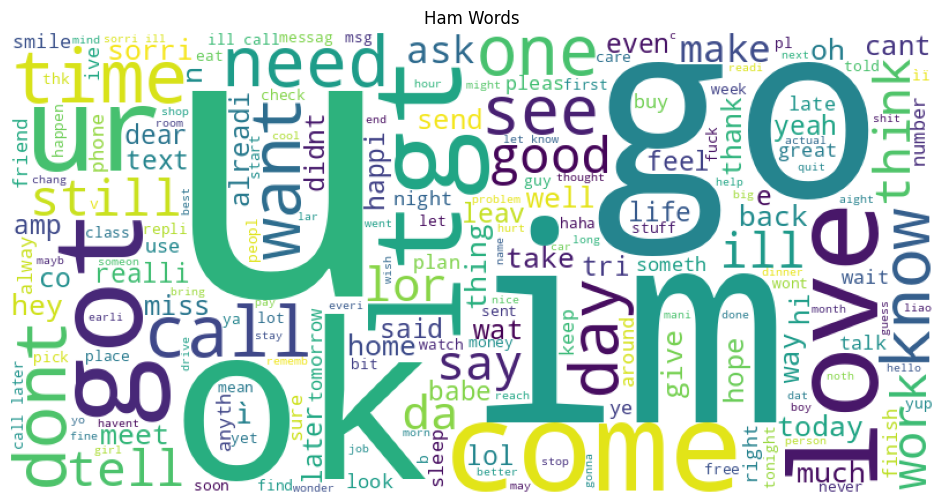

In [22]:
ham_words = " ".join(df[df['label']==0]['clean_message'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Ham Words")
plt.show()

# Discussion

Why is recall important in spam detection?

Recall measures the proportion of actual spam emails that the model correctly identifies. A high recall is important because missing a spam email (false negative) can expose users to phishing attempts, scams, or malicious content. While precision reduces the number of legitimate emails incorrectly marked as spam, recall ensures that most spam messages are successfully detected. In practical email filtering systems, achieving high recall is often prioritized to maximize user safety, while maintaining a balance with precision to avoid excessive false positives.

# Sample Pridiction

In [23]:
sample = ["Congratulations! You have won a FREE iPhone. Claim now."]

sample = [preprocess(i) for i in sample]

sample = tfidf.transform(sample)

prediction = lr.predict(sample)

if prediction[0]==1:
    print("Spam Email")
else:
    print("Ham Email")

Spam Email
